<a href="https://colab.research.google.com/github/RhugvedChavan/Shadow-Fox-/blob/main/Loan_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Loan Approval Prediction**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [4]:
df = pd.read_csv("loan_prediction.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural          

In [5]:
#Handle Missing Values
df = df.fillna({
    "Gender": df["Gender"].mode()[0],
    "Married": df["Married"].mode()[0],
    "Dependents": df["Dependents"].mode()[0],
    "Self_Employed": df["Self_Employed"].mode()[0],
    "LoanAmount": df["LoanAmount"].median(),
    "Loan_Amount_Term": df["Loan_Amount_Term"].median(),
    "Credit_History": df["Credit_History"].median()
})

print("\nMissing values after filling:\n", df.isnull().sum())


Missing values after filling:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [6]:
df.drop("Loan_ID", axis=1, inplace=True)

In [7]:
# Convert Categorical Columns into Numbers
le = LabelEncoder()
categorical_cols = ["Gender", "Married", "Dependents", "Education",
                    "Self_Employed", "Property_Area", "Loan_Status"]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [8]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Train Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))



 Logistic Regression Results
Accuracy: 0.7886178861788617
[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [12]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



 Random Forest Results
Accuracy: 0.7642276422764228
[[18 25]
 [ 4 76]]
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



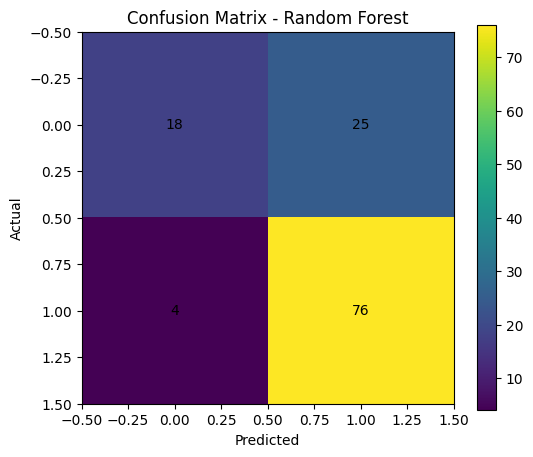

In [13]:
#Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# Show values inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

In [15]:
#Prediction for New Applicant
new_data = pd.DataFrame([[1, 1, 0, 0, 0, 5000, 2000, 150, 360, 1, 2]],
                        columns=X.columns)

new_data_scaled = scaler.transform(new_data)

prediction = rf_model.predict(new_data_scaled)

if prediction[0] == 1:
    print("Loan Approved ")
else:
    print("Loan Rejected ")

Loan Approved 
